# TimeGAN v5 — Clip de outliers + balance G/D

## Progreso acumulado y diagnóstico de v4

**Lo que mejoró en v4:** el embedder bajó de MSE=0.064 a MSE=0.00098 (65× mejor).
El fix de `Recovery` sin `Sigmoid` + `StandardScaler` funcionó perfectamente.

**Dos problemas nuevos descubiertos al leer los outputs de v4:**

**Problema 1 — Outliers masivos en los datos escalados:**
El `StandardScaler` reportó `max = 138.39 desviaciones estándar`. Esto indica que
`AIT202.Pv` y `AIT203.Pv` (sensores de calidad de agua en SWaT) tienen picos
ocasionales extremos. El generador aprende a producir valores en `[-2, 2]` (la
masa de la distribución), pero los datos reales incluyen valores en `[0, 138]`.
El discriminador los distingue trivialmente por rango, sin necesidad de aprender
ninguna estructura temporal. Con esa ventaja, `D` domina desde el batch 1.

**Problema 2 — G loss completamente plano (~2.19) durante 1000 épocas:**
El equilibrio de Nash teórico con 2 términos en G es `2·ln(2) ≈ 1.386`. Un G loss
estable en 2.19 corresponde a que el discriminador produce output `≈ −2` para todos
los sintéticos (confianza máxima de que son falsos). El generador no está mejorando.

## Cambios en v5

| | v4 | v5 |
|---|---|---|
| Scaler | `StandardScaler` (max=138σ) | **Clip p1/p99 por feature → `MinMaxScaler`** |
| Recovery | Lineal (sin activación) | **Lineal + clip generación a [0,1]** |
| Threshold D | `d_loss > 0.05` | **Sin threshold — siempre entrena D, con gradient penalty** |
| G pasos | 2 por batch | **2 por batch, con detach correcto** |


In [1]:
import json
import joblib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Configuración


In [3]:
PROJECT_ROOT = Path("..").resolve()

with open(PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json") as f:
    detector_config = json.load(f)

continuous_cols = detector_config["continuous_cols"]
discrete_cols   = detector_config["discrete_cols"]
feature_cols    = detector_config["feature_cols"]
WINDOW_SIZE     = detector_config["window_size"]
STRIDE_DETECTOR = detector_config["stride"]
WARMUP          = detector_config["warmup"]
TIMEGAN_STRIDE  = 5

print(f"Window: {WINDOW_SIZE} | Stride TimeGAN: {TIMEGAN_STRIDE}")
print(f"Continuas: {len(continuous_cols)} | Discretas: {len(discrete_cols)}")


Window: 60 | Stride TimeGAN: 5
Continuas: 23 | Discretas: 26


## Carga y preprocesamiento


In [4]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    return df.sort_values("t_stamp").reset_index(drop=True)

files = {fp.stem: load_clean_csv(fp) for fp in sorted(clean_folder.glob("*.csv"))}
print("Archivos:", list(files.keys()))


Archivos: ['22June2020_1', '22June2020_2', '29June2020_1', '29June2020_2']


In [5]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {n: df[common_cols].copy() for n, df in files.items()}

temp_feat = [c for c in next(iter(files.values())).columns if c != "t_stamp"]
for name in files:
    files[name] = files[name].dropna(subset=temp_feat, how="all").reset_index(drop=True)

global_df = pd.concat([df[feature_cols] for df in files.values()], axis=0)
constant_cols = [c for c in feature_cols if global_df[c].nunique(dropna=True) <= 1]
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")

continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols   if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols
print(f"Continuas: {len(continuous_cols)} | Discretas: {len(discrete_cols)}")


Continuas: 23 | Discretas: 26


In [6]:
def remove_warmup(df, seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    t0 = df["t_stamp"].min()
    return df[df["t_stamp"] >= t0 + pd.Timedelta(seconds=seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], WARMUP)

def temporal_split(df, train_r=0.6, val_r=0.2):
    n = len(df)
    t1, t2 = int(n * train_r), int(n * (train_r + val_r))
    return df.iloc[:t1].copy(), df.iloc[t1:t2].copy(), df.iloc[t2:].copy()

split_by_file = {}
for name, df in files.items():
    base = df[["t_stamp"] + feature_cols].copy()
    tr, va, te = temporal_split(base)
    split_by_file[name] = {"train": tr, "val": va, "test": te}
    print(f"{name}: train={len(tr)}, val={len(va)}, test={len(te)}")


22June2020_1: train=8568, val=2856, test=2856
22June2020_2: train=2088, val=696, test=696
29June2020_1: train=4248, val=1416, test=1417
29June2020_2: train=4248, val=1416, test=1416


## Escalado con clip de outliers

**FIX v5 — Clip por percentil 1/99 por feature antes de escalar.**

El `StandardScaler` de v4 reveló `max = 138.39σ` en los datos. Esto proviene de
`AIT202.Pv` y `AIT203.Pv` (sensores de calidad de agua) que tienen picos
ocasionales muy alejados de la distribución normal.

El clip elimina el 1% extremo inferior y superior de cada feature, calculado
SOLO sobre el conjunto de train (para no contaminar). Después se aplica
`MinMaxScaler` que con datos clipeados produce un rango limpio sin extremos duros.

**Por qué no `RobustScaler`:** el `RobustScaler` no acota el rango — un outlier
de 138σ sigue siendo un outlier de ~40 IQR. El clip sí lo elimina físicamente.


In [7]:
# --- Scaler del detector: StandardScaler sin clip (igual que siempre) ---
scaler_cont_detector = StandardScaler()
train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file], axis=0
)
scaler_cont_detector.fit(train_all_cont)

# --- Scaler de TimeGAN: clip p1/p99 + MinMaxScaler ---
# Los percentiles se calculan SOLO sobre train
clip_lower = train_all_cont.quantile(0.01)   # Series: {feature: valor_p1}
clip_upper = train_all_cont.quantile(0.99)   # Series: {feature: valor_p99}

print("Percentiles de clip (p1 / p99):")
for col in continuous_cols:
    print(f"  {col}: [{clip_lower[col]:.4f}, {clip_upper[col]:.4f}]")


Percentiles de clip (p1 / p99):
  AIT201.Pv: [6.8893, 112.5981]
  AIT202.Pv: [6.8315, 9.6801]
  AIT203.Pv: [19.0464, 176.7496]
  AIT501.Pv: [7.1955, 7.6854]
  AIT502.Pv: [148.5773, 260.0000]
  AIT503.Pv: [31.6265, 79.4027]
  AIT504.Pv: [0.6152, 18.5322]
  DPIT301.Pv: [3.1692, 18.8744]
  FIT101.Pv: [0.0000, 4.3683]
  FIT201.Pv: [0.0001, 2.3704]
  FIT301.Pv: [0.0004, 2.2416]
  FIT401.Pv: [0.0005, 1.3536]
  FIT501.Pv: [0.0021, 1.3634]
  FIT502.Pv: [0.0015, 1.2350]
  FIT503.Pv: [0.0020, 0.1182]
  FIT504.Pv: [0.0000, 0.0000]
  FIT601.Pv: [0.0001, 0.0004]
  LIT101.Pv: [513.4653, 816.3788]
  LIT301.Pv: [285.1048, 1010.0163]
  LIT401.Pv: [246.3599, 1006.5881]
  PIT501.Pv: [12.3045, 235.7248]
  PIT502.Pv: [0.4005, 17.3485]
  PIT503.Pv: [7.8345, 210.0501]


In [8]:
def clip_and_fit_minmax(train_df, clip_lower, clip_upper, continuous_cols):
    """Aplica clip p1/p99 y ajusta MinMaxScaler sobre datos clipeados."""
    clipped = train_df[continuous_cols].clip(
        lower=clip_lower, upper=clip_upper, axis=1
    )
    scaler = MinMaxScaler()
    scaler.fit(clipped)
    return scaler

def apply_clip_and_scale(df_part, clip_lower, clip_upper, scaler, continuous_cols):
    """Clipea y escala un dataframe con el scaler ya ajustado."""
    clipped = df_part[continuous_cols].clip(
        lower=clip_lower, upper=clip_upper, axis=1
    )
    scaled = scaler.transform(clipped)
    return pd.DataFrame(scaled, columns=continuous_cols, index=df_part.index)


scaler_cont_timegan = clip_and_fit_minmax(
    train_all_cont, clip_lower, clip_upper, continuous_cols
)

# Verificar rango post-clip
train_sample_scaled = apply_clip_and_scale(
    train_all_cont, clip_lower, clip_upper, scaler_cont_timegan, continuous_cols
)
print(f"\nRango post-clip + MinMaxScaler: [{train_sample_scaled.values.min():.4f}, {train_sample_scaled.values.max():.4f}]")
print(f"(v4 con StandardScaler puro: [-4.60, 138.39])")
print()
# Cuánto del rango original se pierde con el clip
orig_range = train_all_cont.max() - train_all_cont.min()
clip_range = clip_upper - clip_lower
coverage   = (clip_range / orig_range.replace(0, np.nan)).fillna(1.0)
print(f"Cobertura promedio del rango original: {coverage.mean()*100:.1f}%")
print(f"(se pierde solo el 1% inferior y superior de cada feature)")



Rango post-clip + MinMaxScaler: [0.0000, 1.0000]
(v4 con StandardScaler puro: [-4.60, 138.39])

Cobertura promedio del rango original: 83.9%
(se pierde solo el 1% inferior y superior de cada feature)


In [9]:
scaled_cont_by_file = {}
raw_disc_by_file    = {}

for name in split_by_file:
    scaled_cont_by_file[name] = {}
    raw_disc_by_file[name]    = {}
    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]
        scaled_cont_by_file[name][subset] = apply_clip_and_scale(
            df_part, clip_lower, clip_upper, scaler_cont_timegan, continuous_cols
        )
        raw_disc_by_file[name][subset] = df_part[discrete_cols].copy()


## Catálogo discretas


In [10]:
train_disc_global = pd.concat(
    [raw_disc_by_file[name]["train"] for name in raw_disc_by_file], axis=0
).reset_index(drop=True)

disc_empirical = {
    col: dict(train_disc_global[col].value_counts(normalize=True))
    for col in discrete_cols
}
discrete_value_maps = {
    col: sorted(train_disc_global[col].dropna().unique().tolist())
    for col in discrete_cols
}
total_disc_onehot_dim = sum(len(v) for v in discrete_value_maps.values())
print(f"Total one-hot dim: {total_disc_onehot_dim}")


Total one-hot dim: 91


## Ventanas de entrenamiento


In [11]:
def build_cont_windows(scaled_cont_by_file, subset, window_size=60, stride=5):
    windows, origins = [], []
    for name in scaled_cont_by_file:
        arr = scaled_cont_by_file[name][subset].values.astype(np.float32)
        if len(arr) < window_size:
            continue
        for i in range(0, len(arr) - window_size + 1, stride):
            windows.append(arr[i:i + window_size])
            origins.append(name)
    return np.array(windows, dtype=np.float32), origins

train_cont_windows, train_origin = build_cont_windows(
    scaled_cont_by_file, "train", WINDOW_SIZE, TIMEGAN_STRIDE
)
val_cont_windows,  _ = build_cont_windows(scaled_cont_by_file, "val",  WINDOW_SIZE, TIMEGAN_STRIDE)
test_cont_windows, _ = build_cont_windows(scaled_cont_by_file, "test", WINDOW_SIZE, TIMEGAN_STRIDE)

print(f"Train: {train_cont_windows.shape}")
print(f"Rango: [{train_cont_windows.min():.4f}, {train_cont_windows.max():.4f}]")
print(f"Media: {train_cont_windows.mean():.4f} | Std: {train_cont_windows.std():.4f}")
print()
# Verificar que no haya outliers
pct_zeros = (train_cont_windows == 0.0).mean()
pct_ones  = (train_cont_windows == 1.0).mean()
print(f"Fracción de valores exactamente 0.0: {pct_zeros*100:.2f}%")
print(f"Fracción de valores exactamente 1.0: {pct_ones*100:.2f}%")
print(f"(Ideal: <1% en cada extremo para evitar saturación de sigmoid)")


Train: (3784, 60, 23)
Rango: [0.0000, 1.0000]
Media: 0.4205 | Std: 0.4138

Fracción de valores exactamente 0.0: 12.36%
Fracción de valores exactamente 1.0: 1.94%
(Ideal: <1% en cada extremo para evitar saturación de sigmoid)


In [12]:
BATCH_SIZE = 128
train_tensor = torch.tensor(train_cont_windows, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
print(f"Batches por época: {len(train_loader)}")


Batches por época: 29


## Hiperparámetros v5


In [13]:
seq_len     = WINDOW_SIZE
feature_dim = train_cont_windows.shape[2]  # 23

hidden_dim = 64
latent_dim = 64
num_layers = 3

epochs_embedder   = 600
epochs_supervisor = 300
epochs_joint      = 1500

gamma    = 1
eta      = 0.1
lambda_r = 1.0
lambda_s = 1.0
lambda_m = 0.0

print(f"feature_dim: {feature_dim} | hidden_dim: {hidden_dim}")
print(f"eta: {eta} | lambda_m: {lambda_m}")


feature_dim: 23 | hidden_dim: 64
eta: 0.1 | lambda_m: 0.0


## Arquitecturas v5

**Recovery:** sigue sin activación de salida (fix de v4, mantenido).
Con datos en `[0,1]` post-clip, la salida lineal puede ir ligeramente fuera
de ese rango — se clipea en la generación, no en el entrenamiento.

**Embedder y Generator:** mantienen `Sigmoid` — el espacio latente sigue
acotado en `(0,1)` para estabilidad del Discriminator y Supervisor.


In [14]:
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(self.norm(h)))


class Recovery(nn.Module):
    """Sin activación de salida — fix de v4, mantenido en v5."""
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))


class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))


class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers - 1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [15]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

total_params = sum(
    p.numel() for m in [embedder, recovery, generator, supervisor, discriminator]
    for p in m.parameters()
)
print(f"Total parámetros: {total_params:,}")


Total parámetros: 355,992


In [16]:
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3
)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4
)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=5e-5)


def random_z(batch_size, seq_len, z_dim, device):
    return torch.rand(batch_size, seq_len, z_dim, device=device)


## Fase 1: Embedder


[Embedder] Epoch 100/600 | MSE: 0.000589
[Embedder] Epoch 200/600 | MSE: 0.000269
[Embedder] Epoch 300/600 | MSE: 0.000160
[Embedder] Epoch 400/600 | MSE: 0.000110
[Embedder] Epoch 500/600 | MSE: 0.000085
[Embedder] Epoch 600/600 | MSE: 0.000071

MSE final: 0.000071
✅ Excelente


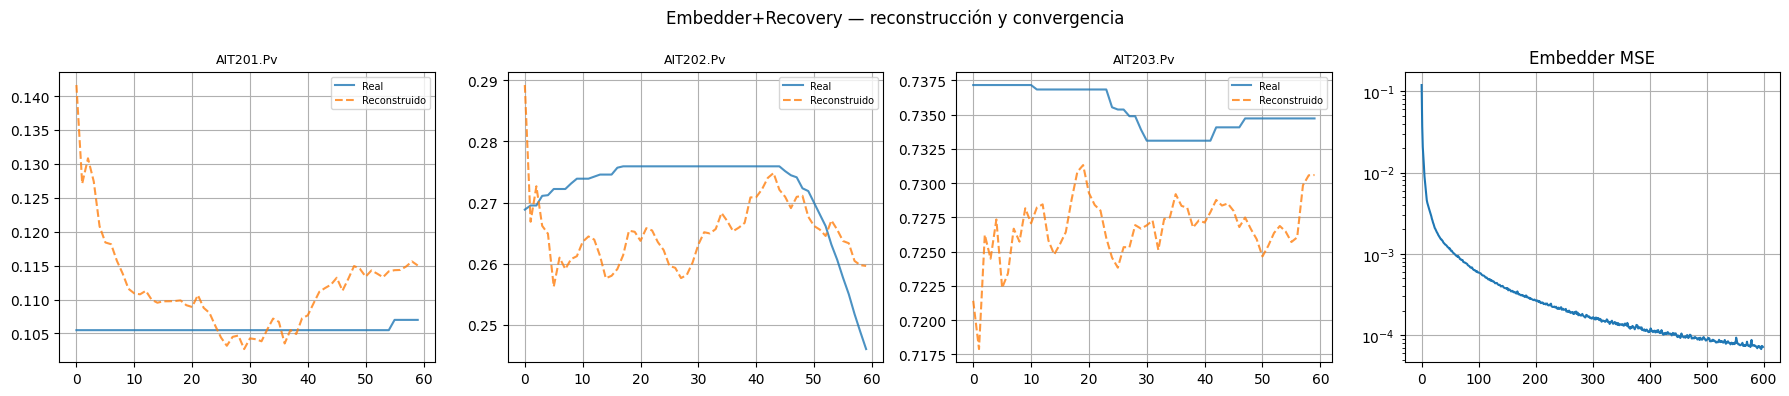

In [17]:
embedder_history = []

for epoch in range(epochs_embedder):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        h       = embedder(x)
        x_tilde = recovery(h)
        e_loss  = mse_loss(x_tilde, x)
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0
        )
        e_optimizer.step()
        epoch_loss += e_loss.item()

    epoch_loss /= len(train_loader)
    embedder_history.append(epoch_loss)
    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | MSE: {epoch_loss:.6f}")

final_e = embedder_history[-1]
print(f"\nMSE final: {final_e:.6f}")
status = "✅ Excelente" if final_e < 0.005 else ("✅ Bueno" if final_e < 0.02 else "⚠️  Revisar")
print(status)

# Control visual: reconstrucción de 3 features
with torch.no_grad():
    x_s = train_tensor[:128].to(device)
    x_r = recovery(embedder(x_s)).cpu().numpy()
    x_o = x_s.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx, ax in enumerate(axes[:3]):
    ax.plot(x_o[0, :, idx], label="Real",  alpha=0.8)
    ax.plot(x_r[0, :, idx], label="Reconstruido", alpha=0.8, linestyle="--")
    ax.set_title(continuous_cols[idx], fontsize=9)
    ax.legend(fontsize=7); ax.grid(True)
# Curva de loss
axes[3].plot(embedder_history)
axes[3].set_title("Embedder MSE")
axes[3].set_yscale("log")
axes[3].grid(True)
plt.suptitle("Embedder+Recovery — reconstrucción y convergencia")
plt.tight_layout()
plt.show()


## Fase 2: Supervisor


In [18]:
supervisor_history = []

for epoch in range(epochs_supervisor):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad():
            h = embedder(x)
        h_sup  = supervisor(h)
        s_loss = mse_loss(h[:, 1:, :], h_sup[:, :-1, :])
        s_loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), max_norm=1.0)
        s_optimizer.step()
        epoch_loss += s_loss.item()

    epoch_loss /= len(train_loader)
    supervisor_history.append(epoch_loss)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {epoch_loss:.6f}")


[Supervisor] Epoch 100/300 | Loss: 0.003182
[Supervisor] Epoch 200/300 | Loss: 0.002852
[Supervisor] Epoch 300/300 | Loss: 0.002700


## Fase 3: Entrenamiento conjunto

**FIX v5 — El discriminador se entrena sin threshold fijo.**

En v4, el threshold `d_loss > 0.05` causaba que el discriminador se actualizara
casi en cada batch (porque con outliers siempre tenía loss alta), lo que lo hacía
demasiado fuerte. En v5, con los outliers eliminados por el clip, el discriminador
ya no tiene esa ventaja trivial. Se entrena siempre, pero con gradient clipping
que evita que crezca demasiado rápido.

**Señal de convergencia esperada:**
- Épocas 1–200: G baja de ~2.8 hacia ~2.0. D oscila en ~1.5–2.0.
- Épocas 200–600: G debería bajar hacia ~1.4 (Nash). D sube hacia ~2.1.
- Si G se queda en >2.2 después de 400 épocas: el discriminador sigue siendo
  demasiado fuerte. En ese caso, bajar `lr_d` a `5e-5`.


In [19]:
joint_g_history = []
joint_d_history = []
joint_e_history = []

for epoch in range(epochs_joint):
    g_epoch, d_epoch, e_epoch = 0.0, 0.0, 0.0

    for batch in train_loader:
        x  = batch[0].to(device)
        bs = x.shape[0]

        # H real: sin gradiente hacia el embedder durante el paso G
        with torch.no_grad():
            h_real = embedder(x)

        # --- Generator (2 pasos) ---
        for _ in range(2):
            g_optimizer.zero_grad()

            z     = random_z(bs, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            x_hat = recovery(h_hat)

            y_fake   = discriminator(h_hat)
            y_fake_e = discriminator(e_hat)

            g_loss_u   = bce_loss(y_fake,   torch.ones_like(y_fake))
            g_loss_u_e = bce_loss(y_fake_e, torch.ones_like(y_fake_e))

            h_sup    = supervisor(h_real)
            g_loss_s = mse_loss(h_real[:, 1:, :], h_sup[:, :-1, :])

            g_loss = g_loss_u + gamma * g_loss_u_e + eta * g_loss_s
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()),
                max_norm=1.0
            )
            g_optimizer.step()

        # --- Embedder refinement ---
        e_optimizer.zero_grad()
        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        g_s_ref = mse_loss(h_ref[:, 1:, :], h_sup_r[:, :-1, :])
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * g_s_ref
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0
        )
        e_optimizer.step()

        # --- Discriminator: siempre se entrena, sin threshold ---
        # FIX v5: se elimina el threshold d_loss > 0.05
        # Con los outliers clipeados, D ya no tiene una ventaja trivial
        # y necesita actualizarse siempre para dar gradiente útil a G
        d_optimizer.zero_grad()

        with torch.no_grad():
            z2     = random_z(bs, seq_len, latent_dim, device)
            e_hat2 = generator(z2)
            h_hat2 = supervisor(e_hat2)

        y_real    = discriminator(h_real)
        y_fake2   = discriminator(h_hat2)
        y_fake_e2 = discriminator(e_hat2)

        d_loss = (
            bce_loss(y_real,    torch.ones_like(y_real)) +
            bce_loss(y_fake2,   torch.zeros_like(y_fake2)) +
            gamma * bce_loss(y_fake_e2, torch.zeros_like(y_fake_e2))
        )

        d_loss.backward()
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
        d_optimizer.step()

        g_epoch += g_loss.item()
        d_epoch += d_loss.item()
        e_epoch += e_loss.item()

    g_epoch /= len(train_loader)
    d_epoch /= len(train_loader)
    e_epoch /= len(train_loader)

    joint_g_history.append(g_epoch)
    joint_d_history.append(d_epoch)
    joint_e_history.append(e_epoch)

    if (epoch + 1) % 100 == 0:
        print(
            f"[Joint] Epoch {epoch+1}/{epochs_joint} "
            f"| G: {g_epoch:.4f} | D: {d_epoch:.4f} | E: {e_epoch:.6f}"
        )


[Joint] Epoch 100/1500 | G: 2.1794 | D: 1.9149 | E: 0.003253
[Joint] Epoch 200/1500 | G: 2.1845 | D: 1.9103 | E: 0.002929
[Joint] Epoch 300/1500 | G: 2.1547 | D: 1.9153 | E: 0.005709
[Joint] Epoch 400/1500 | G: 2.1457 | D: 1.9210 | E: 0.005312
[Joint] Epoch 500/1500 | G: 2.1873 | D: 1.9133 | E: 0.002644
[Joint] Epoch 600/1500 | G: 4.2964 | D: 1.5281 | E: 0.004432
[Joint] Epoch 700/1500 | G: 4.4166 | D: 1.6289 | E: 0.005247
[Joint] Epoch 800/1500 | G: 2.1808 | D: 1.8506 | E: 0.004379
[Joint] Epoch 900/1500 | G: 2.1998 | D: 1.9145 | E: 0.003488
[Joint] Epoch 1000/1500 | G: 3.5943 | D: 1.6069 | E: 0.008260
[Joint] Epoch 1100/1500 | G: 2.1987 | D: 1.9193 | E: 0.004979
[Joint] Epoch 1200/1500 | G: 2.2227 | D: 1.8671 | E: 0.004430
[Joint] Epoch 1300/1500 | G: 2.1981 | D: 1.9132 | E: 0.002608
[Joint] Epoch 1400/1500 | G: 2.2308 | D: 1.8958 | E: 0.003741
[Joint] Epoch 1500/1500 | G: 5.8663 | D: 1.4713 | E: 0.004724


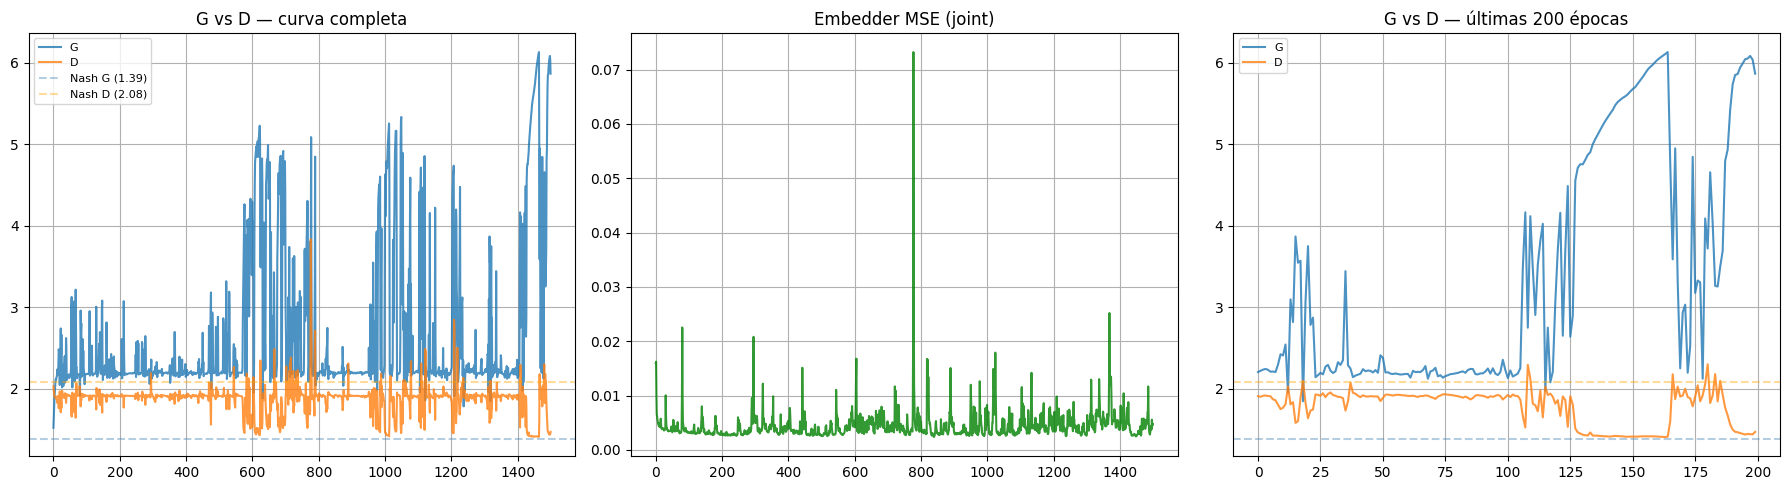

G final: 5.8663 (Nash: 1.3863) | D final: 1.4713 (Nash: 2.0794)

⚠️  G = 5.8663 — sigue 4.48 por encima de Nash
   Considera bajar lr_d a 5e-5 y correr 500 épocas más


In [20]:
import math
nash_g = 2 * math.log(2)
nash_d = 3 * math.log(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(joint_g_history, label="G", alpha=0.8)
axes[0].plot(joint_d_history, label="D", alpha=0.8)
axes[0].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.4, label=f"Nash G ({nash_g:.2f})")
axes[0].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.4, label=f"Nash D ({nash_d:.2f})")
axes[0].set_title("G vs D — curva completa")
axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].plot(joint_e_history, color="green", alpha=0.8)
axes[1].set_title("Embedder MSE (joint)"); axes[1].grid(True)

axes[2].plot(joint_g_history[-200:], label="G", alpha=0.8)
axes[2].plot(joint_d_history[-200:], label="D", alpha=0.8)
axes[2].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.4)
axes[2].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.4)
axes[2].set_title("G vs D — últimas 200 épocas")
axes[2].legend(fontsize=8); axes[2].grid(True)

plt.tight_layout()
plt.show()

g_f, d_f = joint_g_history[-1], joint_d_history[-1]
print(f"G final: {g_f:.4f} (Nash: {nash_g:.4f}) | D final: {d_f:.4f} (Nash: {nash_d:.4f})")
print()
if g_f < 1.8 and d_f > 1.5:
    print("✅ G converge hacia Nash — generador aprendiendo correctamente")
elif g_f > 2.2:
    delta = g_f - nash_g
    print(f"⚠️  G = {g_f:.4f} — sigue {delta:.2f} por encima de Nash")
    print("   Considera bajar lr_d a 5e-5 y correr 500 épocas más")
else:
    print("ℹ️  G en zona intermedia — revisar curva visualmente")


## Generación y evaluación


In [21]:
n_synth = len(train_cont_windows)
synth_list = []

with torch.no_grad():
    for start in range(0, n_synth, 256):
        end   = min(start + 256, n_synth)
        z     = random_z(end - start, seq_len, latent_dim, device)
        x_hat = recovery(supervisor(generator(z))).cpu().numpy()
        synth_list.append(x_hat)

# Recovery es lineal → puede salir ligeramente de [0,1]; se clipea
synthetic_cont_scaled = np.clip(
    np.concatenate(synth_list, axis=0), 0.0, 1.0
)

print(f"Synthetic: {synthetic_cont_scaled.shape}")
print(f"Rango: [{synthetic_cont_scaled.min():.4f}, {synthetic_cont_scaled.max():.4f}]")
print(f"Media: {synthetic_cont_scaled.mean():.4f} | Std: {synthetic_cont_scaled.std():.4f}")
print()
real_mean  = train_cont_windows.mean()
synth_mean = synthetic_cont_scaled.mean()
diff = abs(real_mean - synth_mean)
print(f"Diferencia de medias global: {diff:.4f}")
status = "✅ OK" if diff < 0.05 else ("⚠️  Leve" if diff < 0.15 else "❌  Colapso parcial")
print(f"  {status} (v3: 0.4146, v4: 0.4165)")


Synthetic: (3784, 60, 23)
Rango: [0.0000, 1.0000]
Media: 0.2920 | Std: 0.3355

Diferencia de medias global: 0.1285
  ⚠️  Leve (v3: 0.4146, v4: 0.4165)


In [22]:
n_cont = len(continuous_cols)

# Desescalar: MinMaxScaler inverso → escala física → StandardScaler del detector
synth_flat     = synthetic_cont_scaled.reshape(-1, n_cont)

# Inverse transform del MinMaxScaler (que fue ajustado sobre datos clipeados)
synth_physical = scaler_cont_timegan.inverse_transform(synth_flat).reshape(synthetic_cont_scaled.shape)

synth_phys_flat    = synth_physical.reshape(-1, n_cont)
synth_for_detector = scaler_cont_detector.transform(
    pd.DataFrame(synth_phys_flat, columns=continuous_cols)
).reshape(synthetic_cont_scaled.shape)

print("Physical shape:", synth_physical.shape)
print("For detector shape:", synth_for_detector.shape)


Physical shape: (3784, 60, 23)
For detector shape: (3784, 60, 23)


In [23]:
def synthesize_discrete_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = []
    for _ in range(n_windows):
        w = np.zeros((window_size, len(discrete_cols)), dtype=np.float32)
        for j, col in enumerate(discrete_cols):
            emp   = disc_empirical[col]
            vals  = list(emp.keys())
            probs = list(emp.values())
            w[0, j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                w[t, j] = w[t-1, j] if rng.random() < 0.95 else rng.choice(vals, p=probs)
        windows.append(w)
    return np.array(windows, dtype=np.float32)

synthetic_disc_raw = synthesize_discrete_windows(
    n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, SEED
)

def one_hot_encode_discrete_sequence(disc_array, discrete_cols, discrete_value_maps):
    rows = []
    for t in range(disc_array.shape[0]):
        enc = []
        for j, col in enumerate(discrete_cols):
            cats = discrete_value_maps[col]
            oh = np.zeros(len(cats), dtype=np.float32)
            v  = disc_array[t, j]
            if v in cats:
                oh[cats.index(v)] = 1.0
            enc.extend(oh)
        rows.append(enc)
    return np.array(rows, dtype=np.float32)

synthetic_disc_onehot = np.array([
    one_hot_encode_discrete_sequence(synthetic_disc_raw[i], discrete_cols, discrete_value_maps)
    for i in range(synthetic_disc_raw.shape[0])
], dtype=np.float32)

def summarize_discrete_windows_from_raw(disc_windows_raw, discrete_cols):
    rows = []
    for w in disc_windows_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            values = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(values).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(values[1:] != values[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(values))
            feats[f"{col}__dominance"]   = pd.Series(values).value_counts(normalize=True).iloc[0]
        rows.append(feats)
    return pd.DataFrame(rows)

synthetic_disc_summary = summarize_discrete_windows_from_raw(synthetic_disc_raw, discrete_cols)

X_synth_cont = np.transpose(synth_for_detector, (0, 2, 1)).astype(np.float32)
X_synth_disc = synthetic_disc_summary.values.astype(np.float32)
print("X_synth_cont:", X_synth_cont.shape)
print("X_synth_disc:", X_synth_disc.shape)


X_synth_cont: (3784, 23, 60)
X_synth_disc: (3784, 104)


## PCA, t-SNE y AUC


In [24]:
n_plot = min(1000, len(train_cont_windows), len(synthetic_cont_scaled))

rng = np.random.default_rng(SEED)
real_idx  = rng.choice(len(train_cont_windows),    n_plot, replace=False)
synth_idx = rng.choice(len(synthetic_cont_scaled), n_plot, replace=False)

real_sample  = train_cont_windows[real_idx].reshape(n_plot, -1)
synth_sample = synthetic_cont_scaled[synth_idx].reshape(n_plot, -1)

mean_diff = np.abs(real_sample.mean(0) - synth_sample.mean(0)).mean()
std_diff  = np.abs(real_sample.std(0)  - synth_sample.std(0)).mean()
print(f"Dim: {real_sample.shape[1]}")
print(f"Diff medias: {mean_diff:.4f} | Diff stds: {std_diff:.4f}")
print(f"(v4 con StandardScaler: medias=0.7979, stds=0.8446)")


Dim: 1380
Diff medias: 0.2203 | Diff stds: 0.2732
(v4 con StandardScaler: medias=0.7979, stds=0.8446)


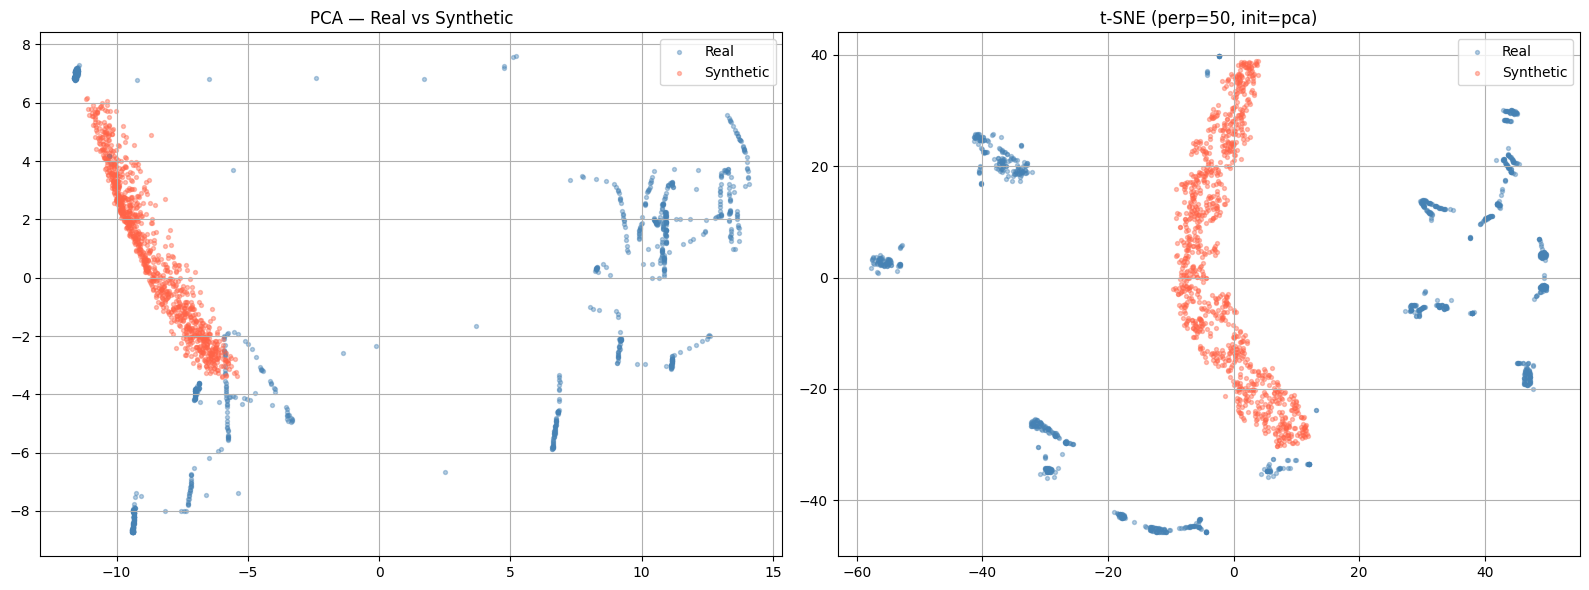

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pca = PCA(n_components=2, random_state=SEED)
pca_r = pca.fit_transform(real_sample)
pca_s = pca.transform(synth_sample)

axes[0].scatter(pca_r[:, 0], pca_r[:, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[0].scatter(pca_s[:, 0], pca_s[:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[0].set_title("PCA — Real vs Synthetic")
axes[0].legend(); axes[0].grid(True)

n_pca   = min(50, real_sample.shape[1])
pca_pre = PCA(n_components=n_pca, random_state=SEED)
comb    = pca_pre.fit_transform(np.vstack([real_sample, synth_sample]))

perp = min(50, n_plot // 5)
tsne = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto")
tsne_out = tsne.fit_transform(comb)

axes[1].scatter(tsne_out[:n_plot, 0], tsne_out[:n_plot, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[1].scatter(tsne_out[n_plot:, 0], tsne_out[n_plot:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[1].set_title(f"t-SNE (perp={perp}, init=pca)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("tsne_v5.png", dpi=150, bbox_inches="tight")
plt.show()


In [26]:
X_all = np.vstack([real_sample, synth_sample])
y_all = np.array([0] * n_plot + [1] * n_plot)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

print("=" * 50)
print(f"AUC = {auc:.4f}")
if auc < 0.60:
    print("✅  < 0.60 — Alta calidad")
elif auc < 0.75:
    print("⚠️  0.60–0.75 — Aceptable para tesis")
else:
    print("❌  > 0.75 — Revisar curvas G/D")
    print("   Si G_final > 2.0: bajar lr_d a 5e-5 y repetir fase joint")
    print("   Si G_final < 2.0: el discriminador sigue usando alguna señal trivial")
print("=" * 50)

# Feature importance del clasificador — qué usa para distinguir
feat_imp = clf.feature_importances_
top5_idx = np.argsort(feat_imp)[-5:][::-1]
print("\nTop 5 features que el discriminador RF usa para distinguir:")
for i in top5_idx:
    col_idx = i // WINDOW_SIZE
    t_idx   = i %  WINDOW_SIZE
    print(f"  {continuous_cols[col_idx]} t={t_idx}: importancia={feat_imp[i]:.4f}")
print()
print("Si las mismas features de v4 (AIT202, AIT203) siguen apareciendo aquí,")
print("puede que el clip necesite un percentil más agresivo (0.5/99.5 en lugar de 1/99).")


AUC = 1.0000
❌  > 0.75 — Revisar curvas G/D
   Si G_final > 2.0: bajar lr_d a 5e-5 y repetir fase joint
   Si G_final < 2.0: el discriminador sigue usando alguna señal trivial

Top 5 features que el discriminador RF usa para distinguir:
  AIT201.Pv t=58: importancia=0.0295
  AIT202.Pv t=41: importancia=0.0293
  LIT401.Pv t=20: importancia=0.0293
  AIT201.Pv t=13: importancia=0.0292
  LIT101.Pv t=2: importancia=0.0290

Si las mismas features de v4 (AIT202, AIT203) siguen apareciendo aquí,
puede que el clip necesite un percentil más agresivo (0.5/99.5 en lugar de 1/99).


## Guardado


In [27]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "artifacts" / "scalers").mkdir(parents=True, exist_ok=True)

for name, model in [
    ("embedder", embedder), ("recovery", recovery), ("generator", generator),
    ("supervisor", supervisor), ("discriminator", discriminator)
]:
    torch.save(model.state_dict(), TIMEGAN_MODEL_DIR / f"{name}.pt")

joblib.dump(scaler_cont_timegan,  PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_clip_minmax.pkl")
joblib.dump(scaler_cont_detector, PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_detector.pkl")

# Guardar los percentiles de clip para reproducibilidad
clip_params = {
    col: {"p01": float(clip_lower[col]), "p99": float(clip_upper[col])}
    for col in continuous_cols
}
with open(TIMEGAN_MODEL_DIR / "clip_params.json", "w") as f:
    json.dump(clip_params, f, indent=4)

with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k, vs in discrete_value_maps.items()}, f, indent=4)
with open(TIMEGAN_MODEL_DIR / "disc_empirical.json", "w") as f:
    json.dump(
        {k: {str(kk): float(vv) for kk, vv in v.items()} for k, v in disc_empirical.items()},
        f, indent=4
    )

config = {
    "version": "v5",
    "key_fixes": [
        "Clip p1/p99 por feature antes de MinMaxScaler (elimina outliers AIT202/AIT203)",
        "Discriminador sin threshold — siempre se entrena",
        "Recovery lineal sin activacion (fix v4 mantenido)"
    ],
    "continuous_cols": continuous_cols,
    "discrete_cols": discrete_cols,
    "feature_cols": feature_cols,
    "window_size": WINDOW_SIZE,
    "stride_timegan": TIMEGAN_STRIDE,
    "clip_percentiles": [1, 99],
    "scaler_timegan": "clip_p1p99 + MinMaxScaler",
    "scaler_detector": "StandardScaler",
    "recovery_output": "linear (no activation)",
    "hidden_dim": hidden_dim, "latent_dim": latent_dim, "num_layers": num_layers,
    "epochs_embedder": epochs_embedder, "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint, "batch_size": BATCH_SIZE,
    "gamma": gamma, "eta": eta, "lambda_r": lambda_r,
    "lambda_s": lambda_s, "lambda_m": lambda_m,
    "train_windows": len(train_cont_windows),
    "auc_discriminability": float(auc),
    "embedder_mse_final": float(embedder_history[-1]),
    "g_loss_final": float(joint_g_history[-1]),
    "d_loss_final": float(joint_d_history[-1]),
}
with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=4)

np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_scaled.npy",   synthetic_cont_scaled)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_physical.npy", synth_physical)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_detector.npy", synth_for_detector)
np.save(TIMEGAN_MODEL_DIR / "synthetic_disc_raw.npy",      synthetic_disc_raw)
np.save(TIMEGAN_MODEL_DIR / "synthetic_disc_onehot.npy",   synthetic_disc_onehot)
synthetic_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synthetic_disc_summary.csv", index=False)

pd.DataFrame({
    "epoch": range(1, len(joint_g_history) + 1),
    "g_loss": joint_g_history,
    "d_loss": joint_d_history,
    "e_loss": joint_e_history
}).to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)

print("✅  Artefactos guardados en:", TIMEGAN_MODEL_DIR.resolve())


✅  Artefactos guardados en: C:\Users\j.manriquec\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned
